In [ ]:
# ── Deep Learning ──────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms

# ── Datos y procesamiento ──────────────────────────────
import numpy as np
from PIL import Image
import os
import json
import random
from tqdm import tqdm

# ── Visualización ──────────────────────────────────────
import matplotlib.pyplot as plt

# ── Verificar GPU ──────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Librerías cargadas")
print(f"🖥️  Dispositivo: {device}")

✅ Librerías cargadas
🖥️  Dispositivo: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/trazos'

# ── Fase 1 ─────────────────────────────────────────────
F1_BASICA = os.path.join(BASE, 'dataset', 'fase1_entrenamiento', 'geometria_basica')
F1_RUIDO  = os.path.join(BASE, 'dataset', 'fase1_entrenamiento', 'ruido')

# ── Fase 2 ─────────────────────────────────────────────
F2_COMPLEJA = os.path.join(BASE, 'dataset', 'fase2_entrenamiento', 'geometria_compleja')
F2_RUIDO    = os.path.join(BASE, 'dataset', 'fase2_entrenamiento', 'ruido_complejo')

# ── Modelos y logs ─────────────────────────────────────
PATH_MODELOS = os.path.join(BASE, 'modelos', 'fase2')
PATH_LOGS    = os.path.join(BASE, 'logs')

# ── Verificar rutas ────────────────────────────────────
rutas = [F1_BASICA, F1_RUIDO, F2_COMPLEJA, F2_RUIDO, PATH_MODELOS, PATH_LOGS]
for r in rutas:
    estado = "✅" if os.path.exists(r) else "❌ NO EXISTE"
    print(f"{estado} — {r}")

Mounted at /content/drive
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/geometria_basica
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/ruido
✅ — /content/drive/MyDrive/trazos/dataset/fase2_entrenamiento/geometria_compleja
✅ — /content/drive/MyDrive/trazos/dataset/fase2_entrenamiento/ruido_complejo
✅ — /content/drive/MyDrive/trazos/modelos/fase2
✅ — /content/drive/MyDrive/trazos/logs


In [ ]:
class TrazosDataset(Dataset):
    """
    Lee pares (input, mask) desde una carpeta con estructura:
        fase/split/inputs/
        fase/split/masks/
    """
    def __init__(self, fase_dir, split, img_size=256):
        self.dir_input = os.path.join(fase_dir, split, 'inputs')
        self.dir_mask  = os.path.join(fase_dir, split, 'masks')
        self.img_size  = img_size
        self.archivos  = sorted(os.listdir(self.dir_input))

        self.transform_img = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])
        self.transform_mask = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        nombre = self.archivos[idx]
        img  = Image.open(os.path.join(self.dir_input, nombre)).convert('RGB')
        mask = Image.open(os.path.join(self.dir_mask,  nombre)).convert('L')
        return self.transform_img(img), self.transform_mask(mask)


# ── Train: Fase 1 + Fase 2 combinados ─────────────────
train_dataset = ConcatDataset([
    TrazosDataset(F1_BASICA,   'train'),   # 1000 imgs
    TrazosDataset(F1_RUIDO,    'train'),   # 1000 imgs
    TrazosDataset(F2_COMPLEJA, 'train'),   # 1000 imgs
    TrazosDataset(F2_RUIDO,    'train'),   # 1000 imgs
])

# ── Val: Fase 1 + Fase 2 combinados ───────────────────
val_dataset = ConcatDataset([
    TrazosDataset(F1_BASICA,   'val'),
    TrazosDataset(F1_RUIDO,    'val'),
    TrazosDataset(F2_COMPLEJA, 'val'),
    TrazosDataset(F2_RUIDO,    'val'),
])

# ── Test por separado para análisis detallado ──────────
test_f1_basica   = TrazosDataset(F1_BASICA,   'test')
test_f1_ruido    = TrazosDataset(F1_RUIDO,    'test')
test_f2_compleja = TrazosDataset(F2_COMPLEJA, 'test')
test_f2_ruido    = TrazosDataset(F2_RUIDO,    'test')

test_dataset = ConcatDataset([
    test_f1_basica, test_f1_ruido,
    test_f2_compleja, test_f2_ruido
])

print(f"✅ Dataset acumulativo cargado")
print(f"   Train : {len(train_dataset):>5} imágenes (F1 + F2)")
print(f"   Val   : {len(val_dataset):>5} imágenes (F1 + F2)")
print(f"   Test  : {len(test_dataset):>5} imágenes (F1 + F2)")
print(f"   Total : {len(train_dataset)+len(val_dataset)+len(test_dataset):>5} imágenes")

✅ Dataset acumulativo cargado
   Train :  4000 imágenes (F1 + F2)
   Val   :   800 imágenes (F1 + F2)
   Test  :   800 imágenes (F1 + F2)
   Total :  5600 imágenes


In [ ]:
BATCH_SIZE  = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f"✅ DataLoaders listos")
print(f"   Batches train : {len(train_loader)}")
print(f"   Batches val   : {len(val_loader)}")
print(f"   Batches test  : {len(test_loader)}")

✅ DataLoaders listos
   Batches train : 250
   Batches val   : 50
   Batches test  : 50


In [ ]:
# Valores reales de versiones anteriores
V1_TEST_IOU  = 0.5833
V1_TEST_DICE = 0.7363
V2_TEST_IOU  = 0.9299
V2_TEST_DICE = 0.9635
BASELINE_IOU = 0.0555

print("=" * 55)
print("📊 HISTORIAL DE VERSIONES")
print("=" * 55)
print(f"{'Versión':<20} {'IoU':>10} {'Dice':>10}")
print("-" * 45)
print(f"{'Baseline Canny':<20} {BASELINE_IOU:>10.4f} {'—':>10}")
print(f"{'v1 CNN':<20} {V1_TEST_IOU:>10.4f} {V1_TEST_DICE:>10.4f}")
print(f"{'v2 U-Net':<20} {V2_TEST_IOU:>10.4f} {V2_TEST_DICE:>10.4f}")
print(f"{'v3 objetivo':<20} {'> 0.90':>10} {'> 0.95':>10}")
print("=" * 55)
print()
print("   ⚠️  Nota: v3 usa datos más difíciles que v2")
print("   Una bajada leve de IoU es normal y esperada")
print("   Lo importante es que aprenda geometría compleja")

📊 HISTORIAL DE VERSIONES
Versión                     IoU       Dice
---------------------------------------------
Baseline Canny           0.0555          —
v1 CNN                   0.5833     0.7363
v2 U-Net                 0.9299     0.9635
v3 objetivo              > 0.90     > 0.95

   ⚠️  Nota: v3 usa datos más difíciles que v2
   Una bajada leve de IoU es normal y esperada
   Lo importante es que aprenda geometría compleja


In [ ]:
class DobleConv(nn.Module):
    """
    Bloque base: dos convoluciones + BatchNorm + ReLU.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.bloque = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.bloque(x)


class UNet(nn.Module):
    """
    U-Net con skip connections.
    Input:  [B, 3, 256, 256]
    Output: [B, 1, 256, 256]
    """
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()

        self.encoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)
        self.decoder = nn.ModuleList()

        ch = in_ch
        for f in features:
            self.encoder.append(DobleConv(ch, f))
            ch = f

        self.bottleneck = DobleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoder.append(DobleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []

        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.decoder), 2):
            x    = self.decoder[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x, size=skip.shape[2:], mode='bilinear', align_corners=False
                )
            x = torch.cat([skip, x], dim=1)
            x = self.decoder[i + 1](x)

        return torch.sigmoid(self.final(x))


modelo = UNet().to(device)

total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"✅ U-Net creada — misma arquitectura que v2")
print(f"   Parámetros entrenables: {total_params:,}")

✅ U-Net creada — misma arquitectura que v2
   Parámetros entrenables: 31,037,633


In [ ]:
def calcular_iou(pred, target, threshold=0.5):
    pred  = (pred > threshold).float()
    inter = (pred * target).sum()
    union = (pred + target).clamp(0, 1).sum()
    return (inter / (union + 1e-8)).item()

def calcular_dice(pred, target, threshold=0.5):
    pred  = (pred > threshold).float()
    inter = (pred * target).sum()
    return (2 * inter / (pred.sum() + target.sum() + 1e-8)).item()

print("✅ Métricas definidas: IoU, Dice Score")

✅ Métricas definidas: IoU, Dice Score


In [ ]:
criterion = nn.BCELoss()

optimizer = optim.Adam(modelo.parameters(), lr=5e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

CONFIG = {
    'version'      : 'v3_unet_acumulativo',
    'epochs'       : 60,
    'batch_size'   : BATCH_SIZE,
    'lr'           : 5e-4,
    'img_size'     : 256,
    'optimizer'    : 'Adam',
    'loss'         : 'BCELoss',
    'patience'     : 10,
    'arquitectura' : 'U-Net features=[64,128,256,512]',
    'dataset'      : 'Fase1 + Fase2 acumulativo',
}

print("✅ Configuración lista")
for k, v in CONFIG.items():
    print(f"   {k:15}: {v}")

✅ Configuración lista
   version        : v3_unet_acumulativo
   epochs         : 60
   batch_size     : 16
   lr             : 0.0005
   img_size       : 256
   optimizer      : Adam
   loss           : BCELoss
   patience       : 10
   arquitectura   : U-Net features=[64,128,256,512]
   dataset        : Fase1 + Fase2 acumulativo


In [ ]:
def entrenar(modelo, train_loader, val_loader, config, path_modelo, path_log):

    mejor_val_loss    = float('inf')
    mejor_val_iou     = 0.0
    epochs_sin_mejora = 0
    historial = {
        'train_loss': [], 'val_loss': [],
        'val_iou'   : [], 'val_dice': []
    }

    for epoch in range(config['epochs']):

        # ── TRAIN ──────────────────────────────────────
        modelo.train()
        train_loss_total = 0

        for imgs, masks in train_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()
            preds = modelo(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item()

        train_loss = train_loss_total / len(train_loader)

        # ── VALIDACIÓN ─────────────────────────────────
        modelo.eval()
        val_loss_total = 0
        iou_total      = 0
        dice_total     = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(device)
                masks = masks.to(device)
                preds = modelo(imgs)
                val_loss_total += criterion(preds, masks).item()
                iou_total      += calcular_iou(preds, masks)
                dice_total     += calcular_dice(preds, masks)

        val_loss = val_loss_total / len(val_loader)
        val_iou  = iou_total      / len(val_loader)
        val_dice = dice_total     / len(val_loader)

        scheduler.step(val_loss)

        historial['train_loss'].append(train_loss)
        historial['val_loss']  .append(val_loss)
        historial['val_iou']   .append(val_iou)
        historial['val_dice']  .append(val_dice)

        print(f"Época {epoch+1:03d}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"IoU: {val_iou:.4f} | "
              f"Dice: {val_dice:.4f}")

        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            epochs_sin_mejora = 0
            torch.save(modelo.state_dict(),
                       os.path.join(path_modelo, f"{config['version']}_best_loss.pth"))
            print(f"           💾 Mejor loss guardado ({mejor_val_loss:.4f})")
        else:
            epochs_sin_mejora += 1

        if val_iou > mejor_val_iou:
            mejor_val_iou = val_iou
            torch.save(modelo.state_dict(),
                       os.path.join(path_modelo, f"{config['version']}_best_iou.pth"))
            print(f"           🎯 Mejor IoU guardado  ({mejor_val_iou:.4f})")

        if epochs_sin_mejora >= config['patience']:
            print(f"\n⛔ EarlyStopping en época {epoch+1}")
            break

    log = {
        'config'         : config,
        'historial'      : historial,
        'mejor_val_loss' : mejor_val_loss,
        'mejor_val_iou'  : mejor_val_iou
    }
    with open(os.path.join(path_log, f"{config['version']}.json"), 'w') as f:
        json.dump(log, f, indent=4)

    print(f"\n✅ Entrenamiento finalizado")
    print(f"   Mejor Val Loss : {mejor_val_loss:.4f}")
    print(f"   Mejor Val IoU  : {mejor_val_iou:.4f}")
    print(f"   Log guardado   : {config['version']}.json")

    return historial


historial = entrenar(modelo, train_loader, val_loader, CONFIG, PATH_MODELOS, PATH_LOGS)

Época 001/60 | Train Loss: 0.2061 | Val Loss: 0.0778 | IoU: 0.6872 | Dice: 0.8125
           💾 Mejor loss guardado (0.0778)
           🎯 Mejor IoU guardado  (0.6872)
Época 002/60 | Train Loss: 0.0479 | Val Loss: 0.0303 | IoU: 0.8300 | Dice: 0.9060
           💾 Mejor loss guardado (0.0303)
           🎯 Mejor IoU guardado  (0.8300)
Época 003/60 | Train Loss: 0.0241 | Val Loss: 0.0193 | IoU: 0.8525 | Dice: 0.9194
           💾 Mejor loss guardado (0.0193)
           🎯 Mejor IoU guardado  (0.8525)
Época 004/60 | Train Loss: 0.0164 | Val Loss: 0.0145 | IoU: 0.8715 | Dice: 0.9307
           💾 Mejor loss guardado (0.0145)
           🎯 Mejor IoU guardado  (0.8715)
Época 005/60 | Train Loss: 0.0128 | Val Loss: 0.0127 | IoU: 0.8832 | Dice: 0.9374
           💾 Mejor loss guardado (0.0127)
           🎯 Mejor IoU guardado  (0.8832)
Época 006/60 | Train Loss: 0.0106 | Val Loss: 0.0102 | IoU: 0.8873 | Dice: 0.9398
           💾 Mejor loss guardado (0.0102)
           🎯 Mejor IoU guardado  (0.8873)
Époc

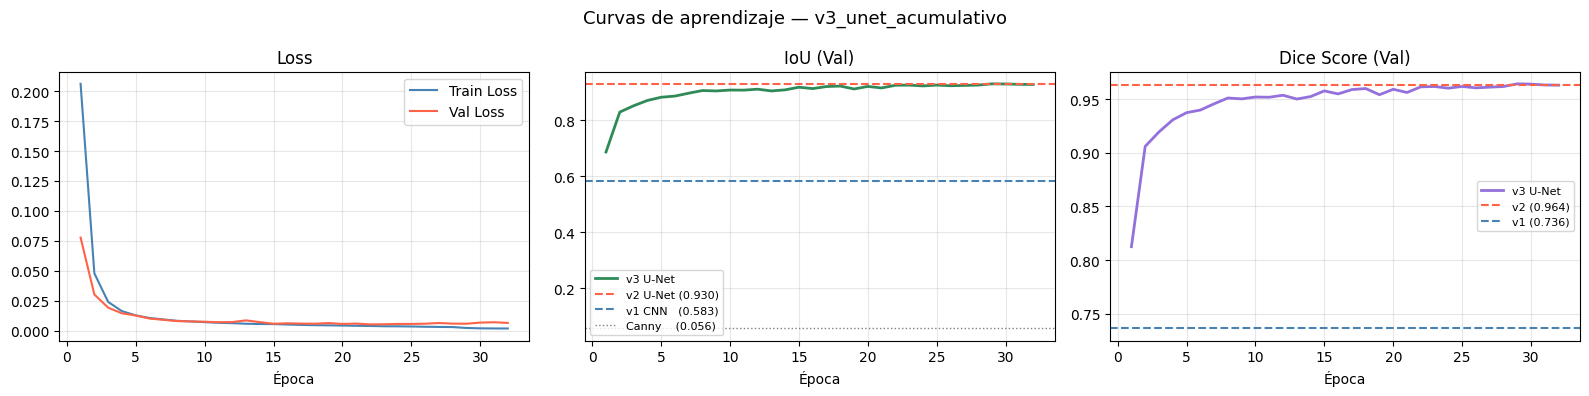

💾 Curvas guardadas en logs/


In [ ]:
def graficar_curvas_v3(historial, config):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Curvas de aprendizaje — {config["version"]}', fontsize=13)
    epochs = range(1, len(historial['train_loss']) + 1)

    # ── Loss ───────────────────────────────────────────
    axes[0].plot(epochs, historial['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs, historial['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── IoU ────────────────────────────────────────────
    axes[1].plot(epochs, historial['val_iou'], color='seagreen', label='v3 U-Net', linewidth=2)
    axes[1].axhline(y=V2_TEST_IOU,  color='tomato',    linestyle='--',
                    label=f'v2 U-Net ({V2_TEST_IOU:.3f})', linewidth=1.5)
    axes[1].axhline(y=V1_TEST_IOU,  color='steelblue', linestyle='--',
                    label=f'v1 CNN   ({V1_TEST_IOU:.3f})', linewidth=1.5)
    axes[1].axhline(y=BASELINE_IOU, color='gray',      linestyle=':',
                    label=f'Canny    ({BASELINE_IOU:.3f})', linewidth=1)
    axes[1].set_title('IoU (Val)')
    axes[1].set_xlabel('Época')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # ── Dice ───────────────────────────────────────────
    axes[2].plot(epochs, historial['val_dice'], color='mediumpurple', label='v3 U-Net', linewidth=2)
    axes[2].axhline(y=V2_TEST_DICE, color='tomato',    linestyle='--',
                    label=f'v2 ({V2_TEST_DICE:.3f})', linewidth=1.5)
    axes[2].axhline(y=V1_TEST_DICE, color='steelblue', linestyle='--',
                    label=f'v1 ({V1_TEST_DICE:.3f})', linewidth=1.5)
    axes[2].set_title('Dice Score (Val)')
    axes[2].set_xlabel('Época')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH_LOGS, f"{config['version']}_curvas.png"), dpi=100)
    plt.show()
    print(f"💾 Curvas guardadas en logs/")

graficar_curvas_v3(historial, CONFIG)

In [ ]:
modelo.load_state_dict(
    torch.load(os.path.join(PATH_MODELOS, f"{CONFIG['version']}_best_iou.pth"))
)
modelo.eval()

def evaluar_dataset(loader, nombre):
    loss_total = 0
    iou_total  = 0
    dice_total = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = modelo(imgs)
            loss_total += criterion(preds, masks).item()
            iou_total  += calcular_iou(preds, masks)
            dice_total += calcular_dice(preds, masks)
    n = len(loader)
    print(f"   {nombre:<25} IoU: {iou_total/n:.4f} | Dice: {dice_total/n:.4f}")
    return iou_total/n, dice_total/n

# DataLoaders individuales para test
test_loader_f1b = DataLoader(test_f1_basica,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_f1r = DataLoader(test_f1_ruido,    batch_size=BATCH_SIZE, shuffle=False)
test_loader_f2c = DataLoader(test_f2_compleja, batch_size=BATCH_SIZE, shuffle=False)
test_loader_f2r = DataLoader(test_f2_ruido,    batch_size=BATCH_SIZE, shuffle=False)

print("=" * 60)
print("📊 EVALUACIÓN FINAL EN TEST — v3 desglosada")
print("=" * 60)
iou_f1b, dice_f1b = evaluar_dataset(test_loader_f1b, 'F1 Geometría Básica')
iou_f1r, dice_f1r = evaluar_dataset(test_loader_f1r, 'F1 Ruido')
iou_f2c, dice_f2c = evaluar_dataset(test_loader_f2c, 'F2 Geometría Compleja')
iou_f2r, dice_f2r = evaluar_dataset(test_loader_f2r, 'F2 Ruido Complejo')

iou_global  = (iou_f1b  + iou_f1r  + iou_f2c  + iou_f2r)  / 4
dice_global = (dice_f1b + dice_f1r + dice_f2c + dice_f2r) / 4

print("-" * 60)
print(f"   {'GLOBAL':<25} IoU: {iou_global:.4f} | Dice: {dice_global:.4f}")
print()
print(f"   Mejora IoU  vs v2: {'+' if iou_global > V2_TEST_IOU else ''}{iou_global - V2_TEST_IOU:.4f}")
print(f"   Mejora Dice vs v2: {'+' if dice_global > V2_TEST_DICE else ''}{dice_global - V2_TEST_DICE:.4f}")
print("=" * 60)

📊 EVALUACIÓN FINAL EN TEST — v3 desglosada
   F1 Geometría Básica       IoU: 0.9390 | Dice: 0.9685
   F1 Ruido                  IoU: 0.9206 | Dice: 0.9585
   F2 Geometría Compleja     IoU: 0.9517 | Dice: 0.9752
   F2 Ruido Complejo         IoU: 0.9201 | Dice: 0.9583
------------------------------------------------------------
   GLOBAL                    IoU: 0.9329 | Dice: 0.9651

   Mejora IoU  vs v2: +0.0030
   Mejora Dice vs v2: +0.0016


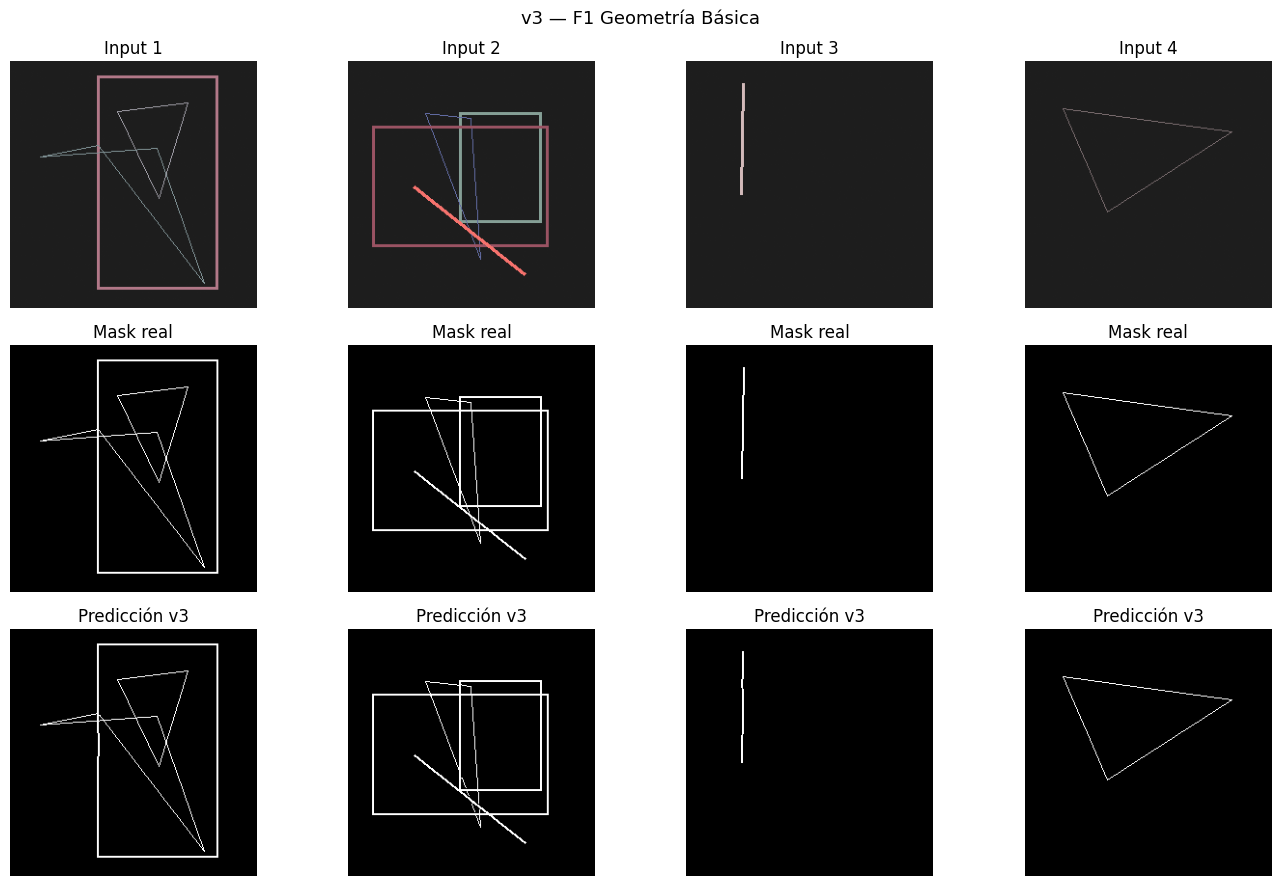

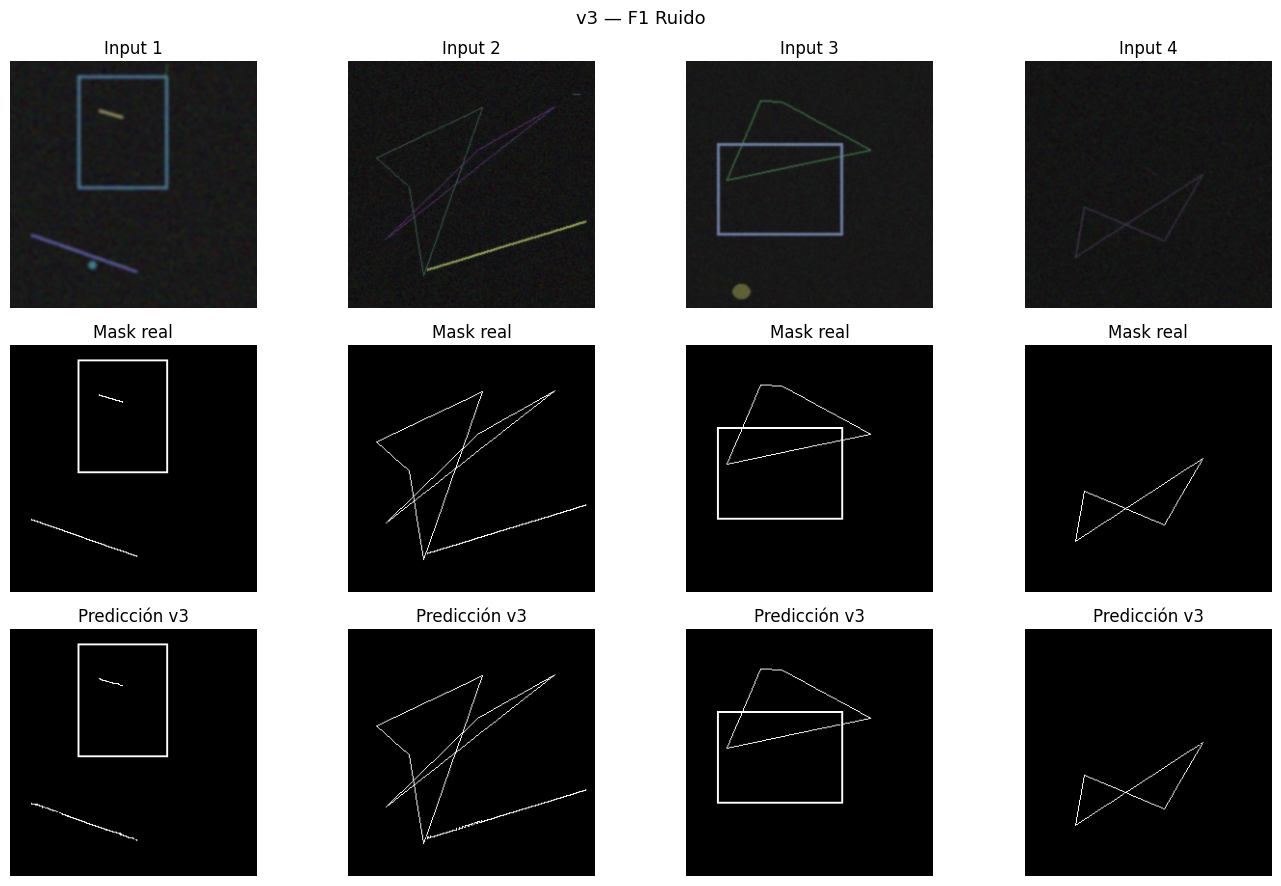

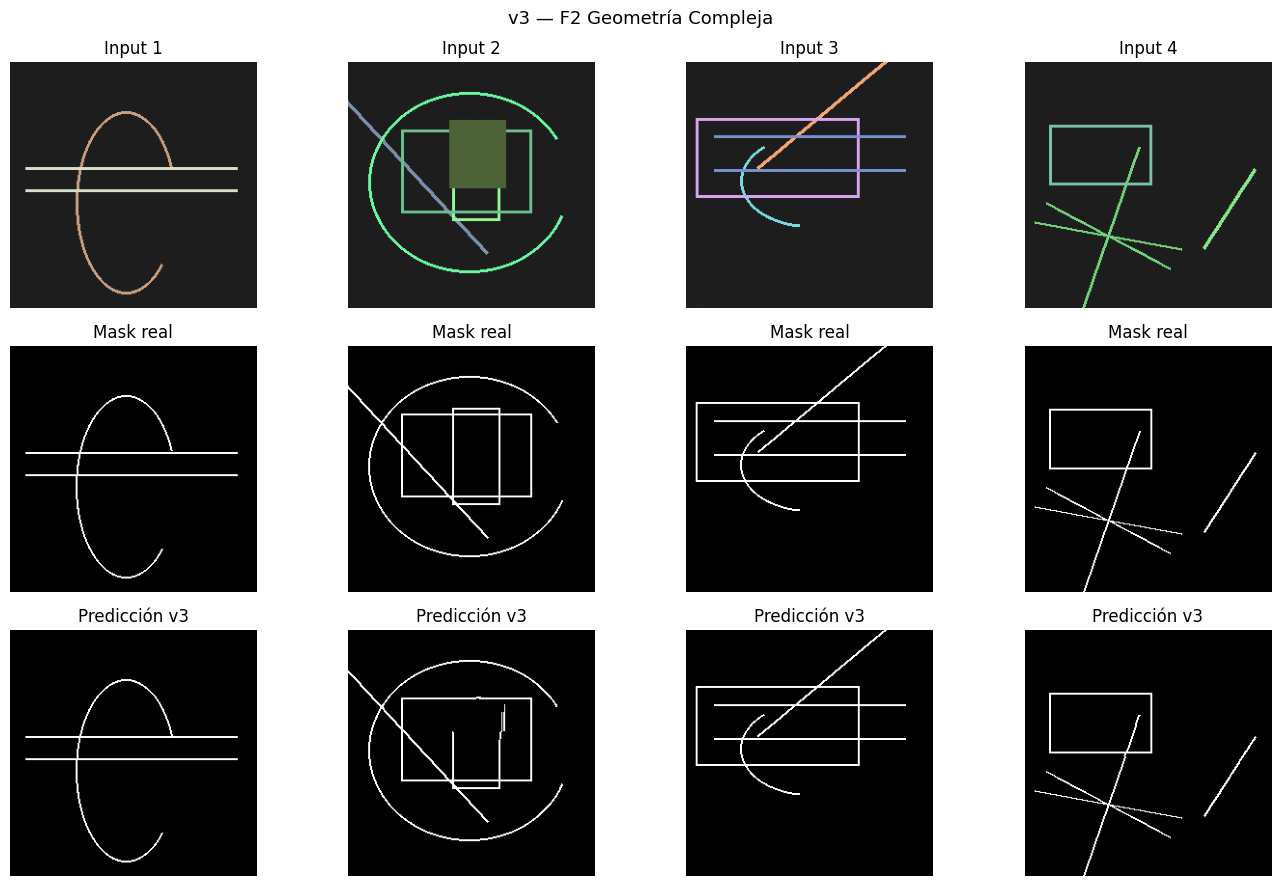

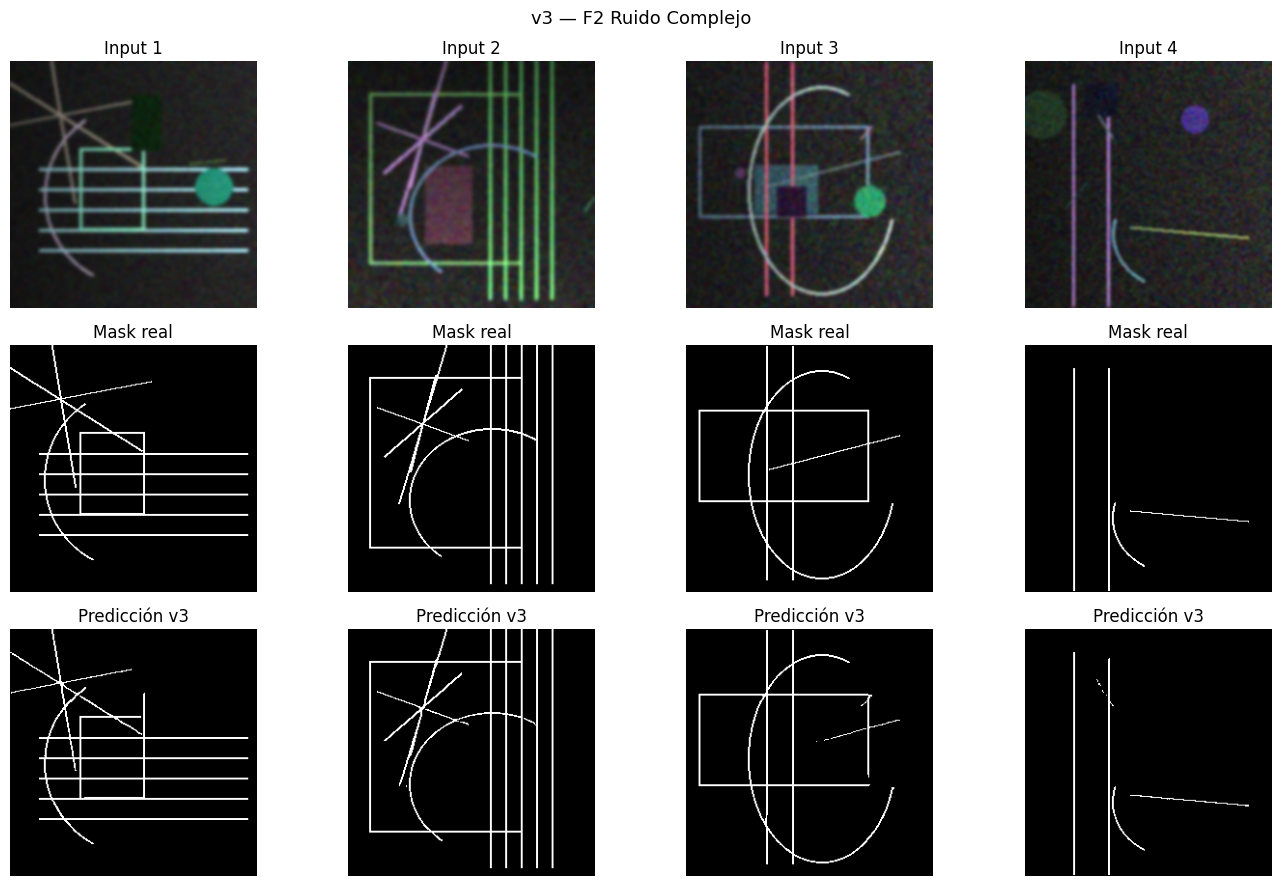

In [ ]:
def visualizar_predicciones(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(titulo, fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred = modelo(img_tensor.unsqueeze(0).to(device))
            pred = pred.squeeze().cpu().numpy()

            img_np   = img_tensor.permute(1, 2, 0).numpy()
            img_np   = (img_np * 0.5 + 0.5).clip(0, 1)
            mask_np  = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)

            axes[0][col].imshow(img_np);             axes[0][col].set_title(f'Input {col+1}'); axes[0][col].axis('off')
            axes[1][col].imshow(mask_np, cmap='gray'); axes[1][col].set_title('Mask real');      axes[1][col].axis('off')
            axes[2][col].imshow(pred_bin, cmap='gray'); axes[2][col].set_title('Predicción v3'); axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

visualizar_predicciones(modelo, test_f1_basica,   'v3 — F1 Geometría Básica')
visualizar_predicciones(modelo, test_f1_ruido,    'v3 — F1 Ruido')
visualizar_predicciones(modelo, test_f2_compleja, 'v3 — F2 Geometría Compleja')
visualizar_predicciones(modelo, test_f2_ruido,    'v3 — F2 Ruido Complejo')

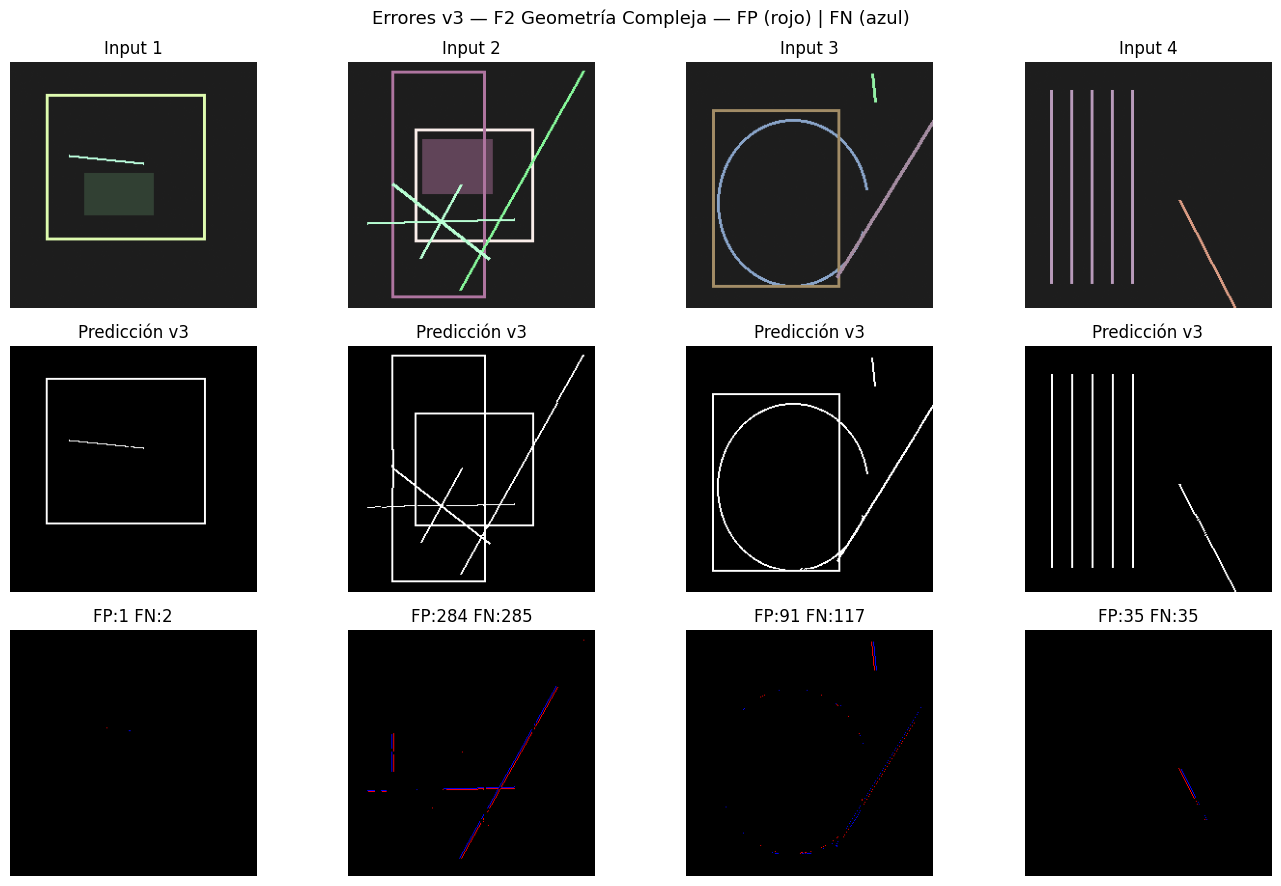

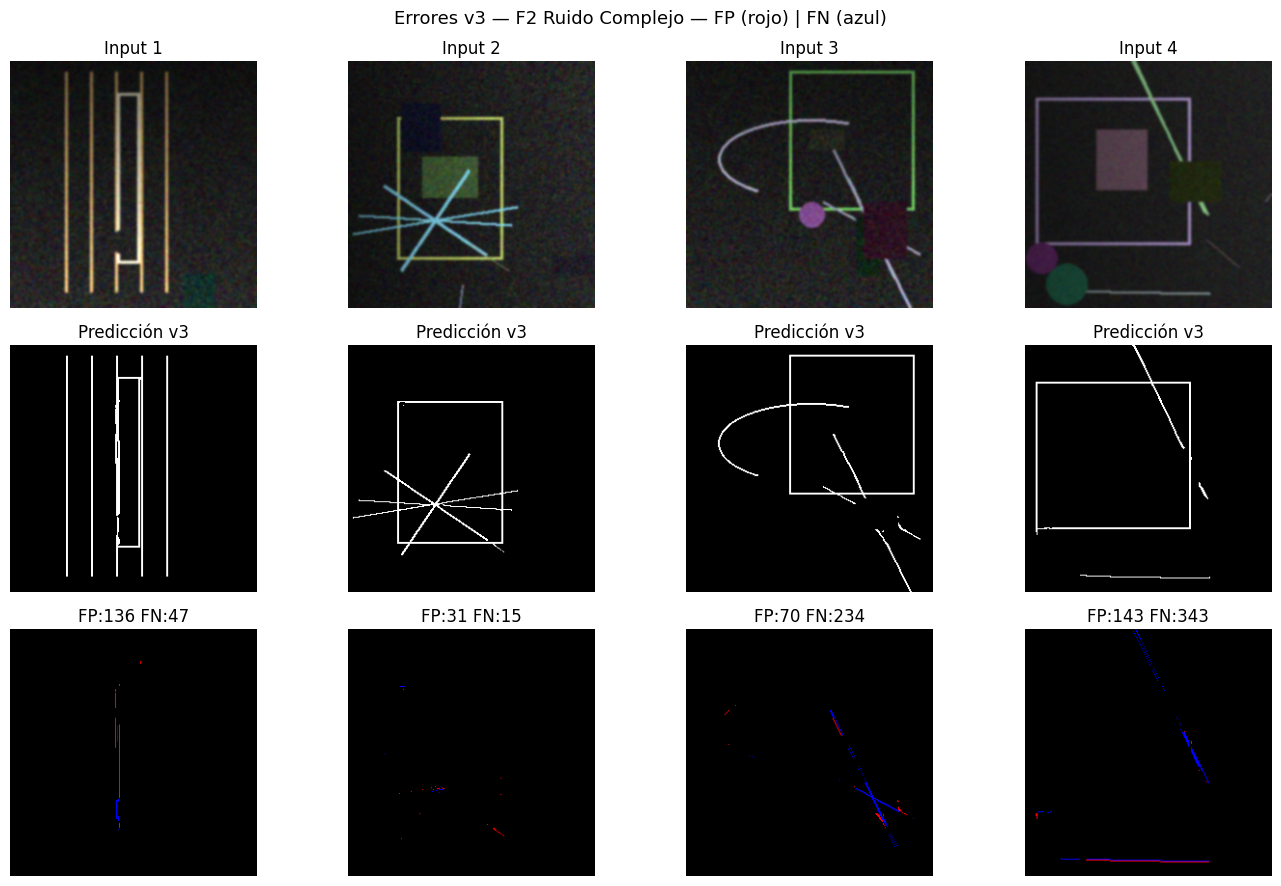

In [ ]:
def analizar_errores(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(f'{titulo} — FP (rojo) | FN (azul)', fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred = modelo(img_tensor.unsqueeze(0).to(device))
            pred = pred.squeeze().cpu().numpy()

            mask_np  = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)
            gt_bin   = (mask_np > 0.5).astype(np.float32)

            fp = ((pred_bin == 1) & (gt_bin == 0)).astype(np.float32)
            fn = ((pred_bin == 0) & (gt_bin == 1)).astype(np.float32)

            error_img = np.zeros((*gt_bin.shape, 3))
            error_img[:, :, 0] = fp
            error_img[:, :, 2] = fn

            img_np = img_tensor.permute(1, 2, 0).numpy()
            img_np = (img_np * 0.5 + 0.5).clip(0, 1)

            axes[0][col].imshow(img_np);   axes[0][col].set_title(f'Input {col+1}'); axes[0][col].axis('off')
            axes[1][col].imshow(pred_bin, cmap='gray'); axes[1][col].set_title('Predicción v3'); axes[1][col].axis('off')
            axes[2][col].imshow(error_img)
            axes[2][col].set_title(f'FP:{int(fp.sum())} FN:{int(fn.sum())}')
            axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

analizar_errores(modelo, test_f2_compleja, 'Errores v3 — F2 Geometría Compleja')
analizar_errores(modelo, test_f2_ruido,    'Errores v3 — F2 Ruido Complejo')

In [ ]:
print("=" * 60)
print("📋 COMPARATIVA COMPLETA DE VERSIONES")
print("=" * 60)
print(f"{'Modelo':<22} {'IoU':>10} {'Dice':>10} {'Dataset':>12}")
print("-" * 58)
print(f"{'Baseline Canny':<22} {BASELINE_IOU:>10.4f} {'—':>10} {'—':>12}")
print(f"{'v1 CNN':<22} {V1_TEST_IOU:>10.4f} {V1_TEST_DICE:>10.4f} {'F1':>12}")
print(f"{'v2 U-Net':<22} {V2_TEST_IOU:>10.4f} {V2_TEST_DICE:>10.4f} {'F1':>12}")
print(f"{'v3 U-Net acumulat.':<22} {iou_global:>10.4f} {dice_global:>10.4f} {'F1+F2':>12}")
print("=" * 60)

comparativa = {
    'baseline' : {'iou': BASELINE_IOU, 'dice': None},
    'v1_cnn'   : {'iou': V1_TEST_IOU,  'dice': V1_TEST_DICE,  'dataset': 'F1'},
    'v2_unet'  : {'iou': V2_TEST_IOU,  'dice': V2_TEST_DICE,  'dataset': 'F1'},
    'v3_unet'  : {'iou': iou_global,   'dice': dice_global,   'dataset': 'F1+F2'},
    'detalle_v3': {
        'f1_basica'  : {'iou': iou_f1b, 'dice': dice_f1b},
        'f1_ruido'   : {'iou': iou_f1r, 'dice': dice_f1r},
        'f2_compleja': {'iou': iou_f2c, 'dice': dice_f2c},
        'f2_ruido'   : {'iou': iou_f2r, 'dice': dice_f2r},
    }
}

with open(os.path.join(PATH_LOGS, 'comparativa_versiones.json'), 'w') as f:
    json.dump(comparativa, f, indent=4)

print(f"\n💾 Comparativa guardada en logs/comparativa_versiones.json")

📋 COMPARATIVA COMPLETA DE VERSIONES
Modelo                        IoU       Dice      Dataset
----------------------------------------------------------
Baseline Canny             0.0555          —            —
v1 CNN                     0.5833     0.7363           F1
v2 U-Net                   0.9299     0.9635           F1
v3 U-Net acumulat.         0.9329     0.9651        F1+F2

💾 Comparativa guardada en logs/comparativa_versiones.json


In [ ]:
def inferencia(ruta_imagen, modelo, threshold=0.5, img_size=256):
    modelo.eval()

    img = Image.open(ruta_imagen).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = modelo(img_tensor).squeeze().cpu().numpy()

    pred_bin = (pred > threshold).astype(np.float32)
    img_np   = np.array(img.resize((img_size, img_size))) / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('Inferencia as_built — v3 U-Net Acumulativo', fontsize=13)

    axes[0].imshow(img_np);              axes[0].set_title('Imagen original'); axes[0].axis('off')
    axes[1].imshow(pred_bin, cmap='gray'); axes[1].set_title('Overlay predicho'); axes[1].axis('off')

    overlay = img_np.copy()
    overlay[pred_bin == 1] = [0, 1, 0]
    axes[2].imshow(overlay); axes[2].set_title('Overlay superpuesto'); axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    return pred_bin

# ── Ejemplo ────────────────────────────────────────────
# resultado = inferencia(
#     '/content/drive/MyDrive/trazos/imagenes_de_ejemplo/Estanteria.png',
#     modelo
# )
print("✅ Función de inferencia lista")
print("   Descomenta las líneas de arriba para ejecutar")

✅ Función de inferencia lista
   Descomenta las líneas de arriba para ejecutar


In [ ]:
resumen_version = """
=======================================================
RESUMEN — as_built | {version}
=======================================================

QUÉ CAMBIÓ RESPECTO A v2:
- Dataset: solo F1 → F1 + F2 acumulativo (doble de datos)
- Se agrega geometría compleja: arcos, paralelas,
  intersecciones, oclusiones, figuras parciales
- Ruido más agresivo: iluminación no uniforme,
  distractores complejos, sombras rectangulares
- Learning rate reducido: 1e-3 → 5e-4
- Épocas aumentadas: 50 → 60
- Evaluación desglosada por tipo de dataset

RESULTADOS GLOBALES:
- Baseline Canny IoU : {baseline}
- v1 CNN IoU         : {v1_iou}
- v2 U-Net IoU       : {v2_iou}
- v3 U-Net IoU       : {v3_iou}
- v3 U-Net Dice      : {v3_dice}
- Mejora IoU v2→v3   : {mejora_iou}

RESULTADOS DESGLOSADOS:
- F1 Geometría Básica : IoU {iou_f1b:.4f} | Dice {dice_f1b:.4f}
- F1 Ruido            : IoU {iou_f1r:.4f} | Dice {dice_f1r:.4f}
- F2 Geometría Compleja: IoU {iou_f2c:.4f} | Dice {dice_f2c:.4f}
- F2 Ruido Complejo   : IoU {iou_f2r:.4f} | Dice {dice_f2r:.4f}

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

ANÁLISIS VISUAL:
- ¿Mejora en arcos y curvas?             (completar)
- ¿Mejora en intersecciones?             (completar)
- ¿Mantiene calidad en geometría básica? (completar)
- ¿Mejora en imagen real estantería?     (completar)

PRÓXIMA FASE:
- Si v3 aprende bien geometría compleja →
  avanzar a Fase 3: simulación de tuberías
- Si v3 falla en oclusiones →
  agregar más ejemplos de oclusión al dataset
=======================================================
""".format(
    version    = CONFIG['version'],
    baseline   = f"{BASELINE_IOU:.4f}",
    v1_iou     = f"{V1_TEST_IOU:.4f}",
    v2_iou     = f"{V2_TEST_IOU:.4f}",
    v3_iou     = f"{iou_global:.4f}",
    v3_dice    = f"{dice_global:.4f}",
    mejora_iou = f"{'+' if iou_global > V2_TEST_IOU else ''}{iou_global - V2_TEST_IOU:.4f}",
    iou_f1b=iou_f1b, dice_f1b=dice_f1b,
    iou_f1r=iou_f1r, dice_f1r=dice_f1r,
    iou_f2c=iou_f2c, dice_f2c=dice_f2c,
    iou_f2r=iou_f2r, dice_f2r=dice_f2r,
)

print(resumen_version)

with open(os.path.join(PATH_LOGS, f"{CONFIG['version']}_notas.txt"), 'w') as f:
    f.write(resumen_version)

print("💾 Notas guardadas en logs/")


RESUMEN — as_built | v3_unet_acumulativo

QUÉ CAMBIÓ RESPECTO A v2:
- Dataset: solo F1 → F1 + F2 acumulativo (doble de datos)
- Se agrega geometría compleja: arcos, paralelas,
  intersecciones, oclusiones, figuras parciales
- Ruido más agresivo: iluminación no uniforme,
  distractores complejos, sombras rectangulares
- Learning rate reducido: 1e-3 → 5e-4
- Épocas aumentadas: 50 → 60
- Evaluación desglosada por tipo de dataset

RESULTADOS GLOBALES:
- Baseline Canny IoU : 0.0555
- v1 CNN IoU         : 0.5833
- v2 U-Net IoU       : 0.9299
- v3 U-Net IoU       : 0.9329
- v3 U-Net Dice      : 0.9651
- Mejora IoU v2→v3   : +0.0030

RESULTADOS DESGLOSADOS:
- F1 Geometría Básica : IoU 0.9390 | Dice 0.9685
- F1 Ruido            : IoU 0.9206 | Dice 0.9585
- F2 Geometría Compleja: IoU 0.9517 | Dice 0.9752
- F2 Ruido Complejo   : IoU 0.9201 | Dice 0.9583

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

ANÁLISIS VISUAL:
- ¿Mejora en 